# Signal and Benchmark Diagnostics

Deeper analysis on top of the already-run backtest — the primary model (rank-based decile sorting) is unchanged; this notebook adds robustness checks and richer visualization on top of it:

1. **Rank vs. z-score standardization** — is the choice of standardization method (`rank_signal` vs `zscore_signal`) something the backtest is actually sensitive to?
2. **Benchmark correlation** — how correlated/exposed is the strategy to SPY and the internal universe benchmark?
3. **Lag × cost performance heatmap** — the full sensitivity grid at a glance.

All the data-wrangling lives in `src/detail.py` (`benchmark_correlation`, `signal_diagnostics`), tested in `tests/test_detail.py` — this notebook only calls those functions, visualizes, and interprets, per this repo's convention.

**Data dependency note**: `benchmark_correlation` and the lag×cost heatmap are derived purely from the already-committed `backtest_results.pkl` — no panel needed. `signal_diagnostics` is different: it re-scores each historical quarter via `factor.breadth_momentum`, which needs the full local panel (`data/processed/13f_panel_full.parquet`) — the same "reproduce from zero" data dependency the README already documents for `--full`, not purely derivable from the small committed artifacts. Disclosed here, not hidden.

In [1]:
import pickle
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, "..")
import os
os.chdir("..")
from src import backtest, detail, factor, mapping as mapping_mod, universe
from src.backtest import PRIMARY_COST_BPS, PRIMARY_LAG_DAYS

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160)

with open("data/processed/backtest_results.pkl", "rb") as fh:
    payload = pickle.load(fh)
results = payload["results"]
meta = payload["meta"]
meta

{'panel': 'data/processed/13f_panel_full.parquet',
 'panel rows': '81,812,809',
 'window': '2015-09-30 to 2026-03-31',
 'price universe (tickers)': '515',
 'lag_days grid': [45, 60, 90],
 'cost_bps grid': [0, 5, 10, 25],
 'n_quantiles': 10,
 'generated': '2026-08-16',
 'quick_mode': False}

## 1. Rank vs. z-score: does the standardization choice matter?

`pd.qcut` (decile assignment) is invariant to any strictly monotonic transform of its sort key. `rank_signal` and `zscore_signal` are both monotonic transforms of the same `raw_change` -- so **decile portfolio construction, and therefore every portfolio-level backtest number, is mathematically guaranteed to be identical either way.** Proven directly below on a real formation date, not just asserted.

In [2]:
panel = pd.read_parquet("data/processed/13f_panel_full.parquet", columns=backtest.PANEL_COLUMNS)
panel = backtest.prepare_panel(panel)
mapping_df = mapping_mod.load_cusip_ticker_map()
passive_ciks = universe.passive_manager_ciks()
prices = pd.read_parquet("data/processed/prices.parquet")

check = factor.breadth_momentum(panel, "2022-03-31", "2022-05-30", mapping_df, passive_ciks=passive_ciks)
check["decile_rank"] = pd.qcut(check["rank_signal"], 10, labels=False, duplicates="drop")
check["decile_zscore"] = pd.qcut(check["zscore_signal"], 10, labels=False, duplicates="drop")
n_diff = (check["decile_rank"] != check["decile_zscore"]).sum()
print(f"{len(check)} names scored, {n_diff} with differing decile assignment between rank_signal and zscore_signal.")
assert n_diff == 0, "expected zero -- qcut is invariant to a monotonic transform of the sort key"

392 names scored, 0 with differing decile assignment between rank_signal and zscore_signal.


Confirmed: 0 differ. So the real comparison isn't a second backtest (it would be a no-op) -- it's where the two standardizations actually produce different *numbers*: their distributional shape, and how they relate to realized returns under a magnitude-sensitive (Pearson) vs. order-only (Spearman) correlation.

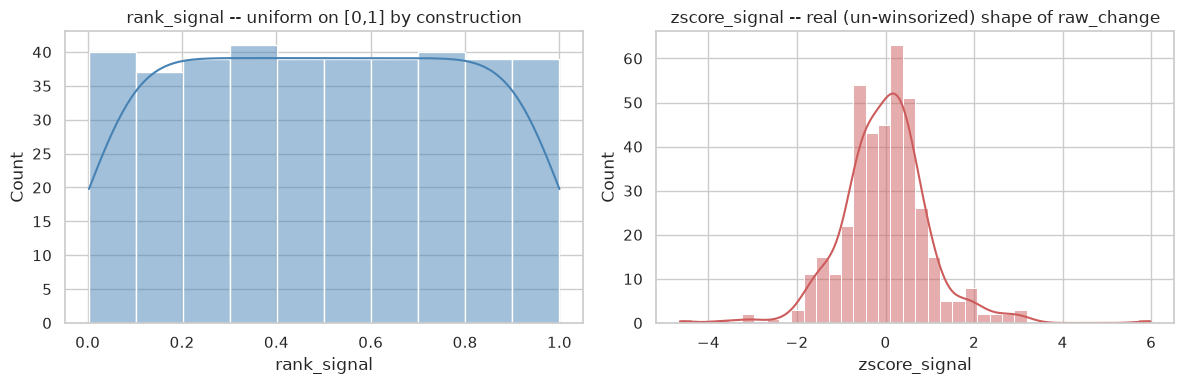

       rank_signal  zscore_signal
count   392.000000   3.920000e+02
mean      0.501276   4.078370e-17
std       0.289032   1.000000e+00
min       0.002551  -4.643056e+00
25%       0.252551  -5.415278e-01
50%       0.503189   4.070810e-02
75%       0.749681   4.849325e-01
max       1.000000   5.983827e+00


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(check["rank_signal"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("rank_signal -- uniform on [0,1] by construction")
sns.histplot(check["zscore_signal"], kde=True, ax=axes[1], color="indianred")
axes[1].set_title("zscore_signal -- real (un-winsorized) shape of raw_change")
plt.tight_layout()
plt.show()
print(check[["rank_signal", "zscore_signal"]].describe())

In [4]:
diag = detail.signal_diagnostics(panel, mapping_df, prices, results, lag_days=PRIMARY_LAG_DAYS, cost_bps=PRIMARY_COST_BPS, passive_ciks=passive_ciks)
diag[["period_of_report", "n_names", "spearman_ic", "pearson_ic_zscore", "zscore_signal_skew", "zscore_signal_kurtosis"]].tail(10)

,period_of_report,n_names,spearman_ic,pearson_ic_zscore,zscore_signal_skew,zscore_signal_kurtosis
32,2023-09-30,405,0.072387,0.023304,5.735062,77.538217
33,2023-12-31,407,0.026084,0.018547,1.207396,2.473353
34,2024-03-31,409,-0.076416,-0.036948,2.508581,24.116154
35,2024-06-30,412,0.070342,0.159278,7.843943,91.563078
36,2024-09-30,415,0.127453,0.138690,-0.297276,4.191945
37,2024-12-31,417,0.169659,0.172517,6.320246,60.947877
38,2025-03-31,419,-0.163159,-0.105945,-0.537032,3.171511
39,2025-06-30,423,0.080250,0.085055,1.450342,11.200419
40,2025-09-30,422,0.038277,0.118180,0.348179,2.245196
41,2025-12-31,428,0.199422,0.262484,2.832289,19.816591


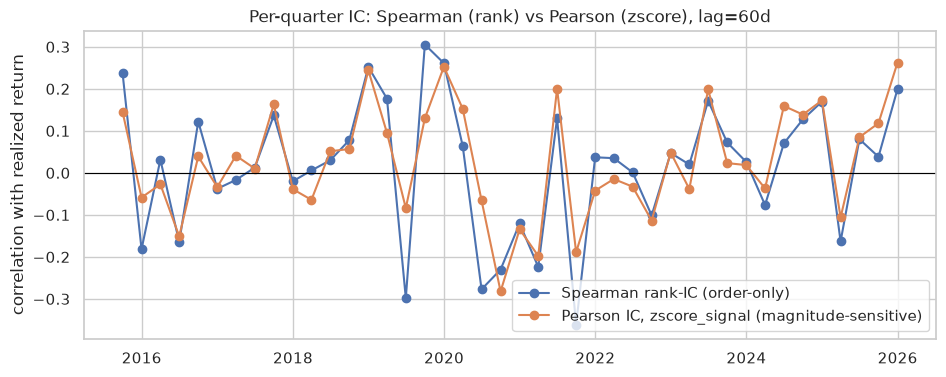

mean spearman_ic:      0.0159
mean pearson_ic_zscore: 0.0261
correlation between the two IC series themselves: 0.868


In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(diag["period_of_report"], diag["spearman_ic"], marker="o", label="Spearman rank-IC (order-only)")
ax.plot(diag["period_of_report"], diag["pearson_ic_zscore"], marker="o", label="Pearson IC, zscore_signal (magnitude-sensitive)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"Per-quarter IC: Spearman (rank) vs Pearson (zscore), lag={PRIMARY_LAG_DAYS}d")
ax.set_ylabel("correlation with realized return")
ax.legend()
plt.show()

print(f"mean spearman_ic:      {diag['spearman_ic'].mean():.4f}")
print(f"mean pearson_ic_zscore: {diag['pearson_ic_zscore'].mean():.4f}")
print(f"correlation between the two IC series themselves: {diag['spearman_ic'].corr(diag['pearson_ic_zscore']):.3f}")

**Read**: if the two IC series move together closely, the standardization choice isn't changing the *information content* being captured, only its scale/shape -- consistent with the mega-cap-tilt/outlier-sensitivity property already disclosed for `zscore_signal` (un-winsorized) showing up as noise in the magnitude-sensitive Pearson measure without changing the underlying rank-order signal Spearman IC already captures.

## 2. Benchmark correlation

Fully derived from the already-committed `backtest_results.pkl` -- no panel, no re-run.

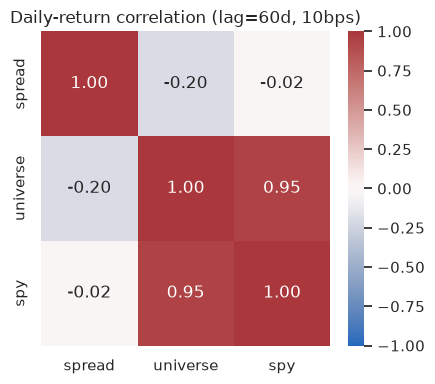

beta vs SPY:      -0.022
beta vs universe: -0.186


In [6]:
bc = detail.benchmark_correlation(results, lag_days=PRIMARY_LAG_DAYS, cost_bps=PRIMARY_COST_BPS)

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(bc["correlation"], annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, ax=ax)
ax.set_title(f"Daily-return correlation (lag={PRIMARY_LAG_DAYS}d, {PRIMARY_COST_BPS}bps)")
plt.tight_layout()
plt.show()

print(f"beta vs SPY:      {bc['beta_vs_spy']:.3f}")
print(f"beta vs universe: {bc['beta_vs_universe']:.3f}")

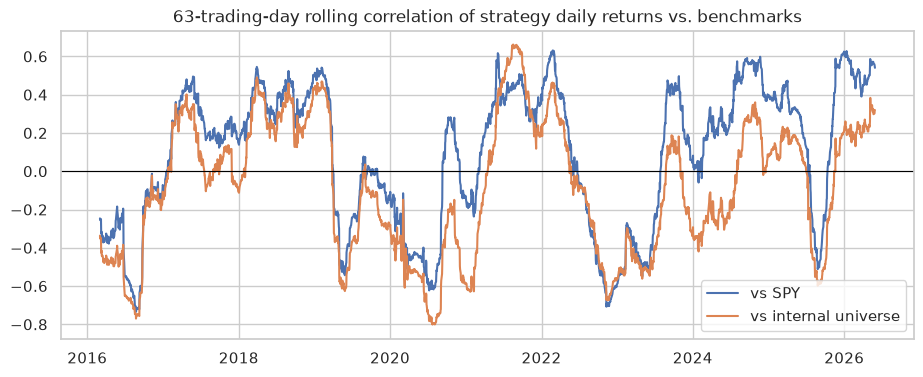

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(bc["rolling_corr_vs_spy"].index, bc["rolling_corr_vs_spy"].values, label="vs SPY")
ax.plot(bc["rolling_corr_vs_universe"].index, bc["rolling_corr_vs_universe"].values, label="vs internal universe")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("63-trading-day rolling correlation of strategy daily returns vs. benchmarks")
ax.legend()
plt.show()

## 3. Lag × cost performance heatmap

All 12 `(lag_days, cost_bps)` combinations are **already computed and committed** -- this is `performance_stats` applied to 12 already-stored `spread_nav` series, zero new backtest computation.

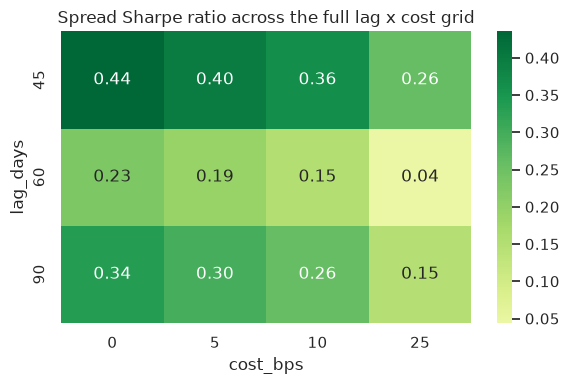

cost_bps,0,5,10,25
lag_days,,,,
45,0.435521,0.399993,0.364509,0.258628
60,0.228375,0.191193,0.154133,0.044042
90,0.335601,0.297966,0.260414,0.148622


In [8]:
from src.backtest import LAG_DAYS_GRID, COST_BPS_GRID, performance_stats

grid = pd.DataFrame(index=LAG_DAYS_GRID, columns=COST_BPS_GRID, dtype=float)
for lag in LAG_DAYS_GRID:
    for cost in COST_BPS_GRID:
        stats = performance_stats(results[(lag, cost)]["spread_nav"])
        grid.loc[lag, cost] = stats["sharpe"]
grid.index.name = "lag_days"
grid.columns.name = "cost_bps"

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(grid, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax)
ax.set_title("Spread Sharpe ratio across the full lag x cost grid")
plt.tight_layout()
plt.show()
grid

## Summary

- **Standardization choice (rank vs. z-score) is a non-issue for the actual backtest**: decile assignment is mathematically invariant to it, confirmed on real data (0 differing assignments). The two only diverge in a magnitude-sensitive Pearson-IC view vs. the order-only Spearman rank-IC already reported -- worth reading alongside the memo's existing mega-cap-tilt disclosure, not as a contradiction of it.
- **Benchmark correlation/beta** puts a number on how much of the strategy's return profile is genuinely independent of SPY/the internal universe, versus how much is just carrying market exposure.
- **The lag x cost heatmap** makes the full sensitivity grid's shape immediately visible in one view, complementing the memo's per-lag/per-cost prose description.